### IMPORTS

In [3]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from collections import Counter

nltk.download('stopwords', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay ,classification_report
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from gensim.models import Word2Vec, FastText

# Style global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from sentence_transformers import SentenceTransformer


c:\Users\firas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### LOAD DATA

In [4]:
df_clean = pd.read_csv("../data/df_clean.csv")

text_col = "Rapport_Collecte"
target   = "Categorie"

X = df_clean[text_col].astype(str)
y = df_clean[target]

print(f"Dimensions : {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes")

Dimensions : 9724 lignes x 9 colonnes


### SPLIT

In [5]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(X_train.shape, X_val.shape, X_test.shape)

(6806,) (1459,) (1459,)


### PRÉTRAITEMENT TEXTUEL

Pipeline : normalisation → tokenisation → suppression des stopwords (français + domaine) → stemming (FrenchStemmer)

In [6]:
# ─── STOPWORDS FRANÇAIS (NLTK) ───────────────────────────────────────────────
STOPWORDS_FR = set(stopwords.words("french"))


STOPWORDS_DOMAINE = {

    # administratif
    "rapport","collecte","observation","note","constat",
    "visite","lot","provenance","provenant","issu","origine",

    # lieux
    "site","zone","secteur","centre","usine","municipal",
    "localisation","emplacement",

    # organisation
    "agent","équipe","general","général",

    # qualité
    "standard","standards","conforme",
    "verification","vérification",
    "recommandee","recommandée",
    "prioritaire",

    # mesures déjà présentes en colonnes numériques
    "poids","volume","masse","kg","l",
    "mesuré","mesure","estimé","estime",

    # intensité inutile
    "très","extremement","extrêmement",
    "moyen","moyenne","faible","élevée",

    # mots vides dataset
    "non","aucune","aucun","sans"
}

STOPWORDS_TOUS = STOPWORDS_FR | STOPWORDS_DOMAINE

stemmer = FrenchStemmer()


def preprocess(text: str) -> str:
    """
    Pipeline NLP :
    1. Mise en minuscules
    2. Suppression des caractères non-alphabétiques (garde accents français)
    3. Tokenisation par split
    4. Suppression des stopwords FR + domaine (version corrigée)
    5. Suppression des tokens ≤ 2 caractères
    6. Stemming FrenchStemmer (NLTK Snowball)
    Retourne une chaîne de tokens traités rejoints par espaces.
    """
    text = text.lower()
    text = re.sub(r"[^a-zàâäéèêëîïôùûüç\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_TOUS and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)


# Application sur les trois partitions
X_train_clean = X_train.apply(preprocess)
X_val_clean   = X_val.apply(preprocess)
X_test_clean  = X_test.apply(preprocess)

# Vérification rapide
print("Avant :", X_train.iloc[0])
print("Après :", X_train_clean.iloc[0])
print(f"\nVocabulaire train : {len(set(' '.join(X_train_clean).split()))} tokens uniques")

Avant : Lot de verre trié en provenance de l'Usine A. Masse 185.6 kg. Matériau lourd et extrêmement rigide. Aspect indéterminée. Étiquetage absent sur le conteneur.
Après : verr tri matériau lourd rigid aspect indétermin étiquetag absent conteneur

Vocabulaire train : 116 tokens uniques


### Configuration des Modèles et MLflow

In [7]:

import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
exp = mlflow.set_experiment("EcoSmart_NLP_Vectorisation")

print(" MLflow experiment initialisé")

models_text = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

models_emb = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

def evaluate(model, Xtr, Xte, ytr, yte,
             representation="unknown",
             model_name="unknown",
             log_mlflow=True):

    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    acc  = accuracy_score(yte, pred)
    prec = precision_score(yte, pred, average="weighted", zero_division=0)
    rec  = recall_score(yte, pred, average="weighted", zero_division=0)
    f1   = f1_score(yte, pred, average="weighted", zero_division=0)

    if log_mlflow:
        with mlflow.start_run(experiment_id=exp.experiment_id, run_name=f"{representation}_{model_name}"):
            mlflow.set_tag("representation", representation, )
            mlflow.set_tag("model_name", model_name, )
            mlflow.set_tag("dataset", "EcoSmart")
            mlflow.set_tag("task", "text_classification")

            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("precision", prec)
            mlflow.log_metric("recall", rec)
            mlflow.log_metric("f1", f1)

    return acc, prec, rec, f1

 MLflow experiment initialisé


### BAG OF WORDS (BASELINE)

In [8]:
print("\n=== BAG OF WORDS ===")

bow = CountVectorizer()

X_train_bow = bow.fit_transform(X_train_clean)
X_test_bow  = bow.transform(X_test_clean)

results_bow = {}

for name, model in models_text.items():
    acc, prec, rec, f1 = evaluate(model, X_train_bow, X_test_bow, y_train, y_test, representation="BoW", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_bow[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== BAG OF WORDS ===

=== Naive Bayes ===
Accuracy : 0.9650
Precision: 0.9666
Recall   : 0.9650
F1-score : 0.9653

=== Logistic Regression ===
Accuracy : 0.9623
Precision: 0.9635
Recall   : 0.9623
F1-score : 0.9625

=== Linear SVC ===
Accuracy : 0.9623
Precision: 0.9635
Recall   : 0.9623
F1-score : 0.9625

=== Random Forest ===
Accuracy : 0.9644
Precision: 0.9647
Recall   : 0.9644
F1-score : 0.9644


#### Matrice de Confusion — Meilleur modèle bag of word

 Meilleur modèle BoW : Naive Bayes (F1=0.9653)


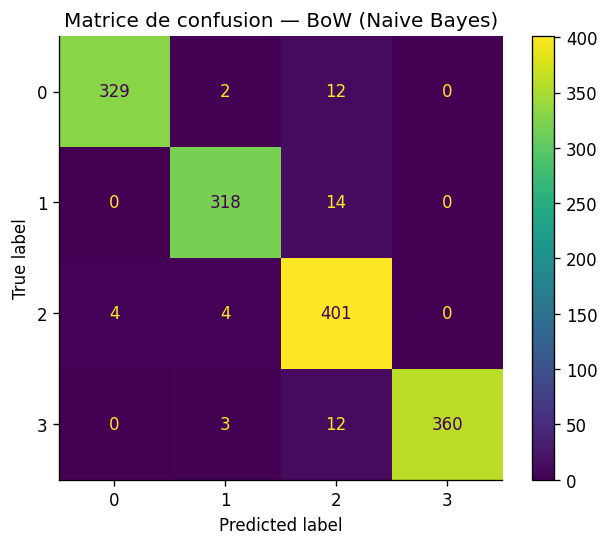


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       343
           1       0.97      0.96      0.97       332
           2       0.91      0.98      0.95       409
           3       1.00      0.96      0.98       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [9]:
# MEILLEUR MODÈLE BOw
best_model_name = max(results_bow, key=lambda x: results_bow[x]["F1-score"])

print(" Meilleur modèle BoW :", best_model_name,
      f"(F1={results_bow[best_model_name]['F1-score']:.4f})")

best_model = models_text[best_model_name]
best_model.fit(X_train_bow, y_train)
y_pred_best = best_model.predict(X_test_bow)

# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Matrice de confusion — BoW ({best_model_name})")
plt.show()

# CLASSIFICATION REPORT
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

### TF-IDF (REFERENCE)

In [10]:
print("\n=== TF-IDF ===")

tfidf = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

results_tfidf = {}

for name, model in models_text.items():
    acc, prec, rec, f1 = evaluate(model, X_train_tfidf, X_test_tfidf, y_train, y_test, representation="TF-IDF", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_tfidf[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== TF-IDF ===

=== Naive Bayes ===
Accuracy : 0.9616
Precision: 0.9634
Recall   : 0.9616
F1-score : 0.9619

=== Logistic Regression ===
Accuracy : 0.9630
Precision: 0.9656
Recall   : 0.9630
F1-score : 0.9635

=== Linear SVC ===
Accuracy : 0.9637
Precision: 0.9644
Recall   : 0.9637
F1-score : 0.9638

=== Random Forest ===
Accuracy : 0.9650
Precision: 0.9655
Recall   : 0.9650
F1-score : 0.9651


#### Matrice de Confusion — Meilleur modèle TF-IDF


Meilleur modèle TF-IDF : Random Forest avec F1-score=0.9651


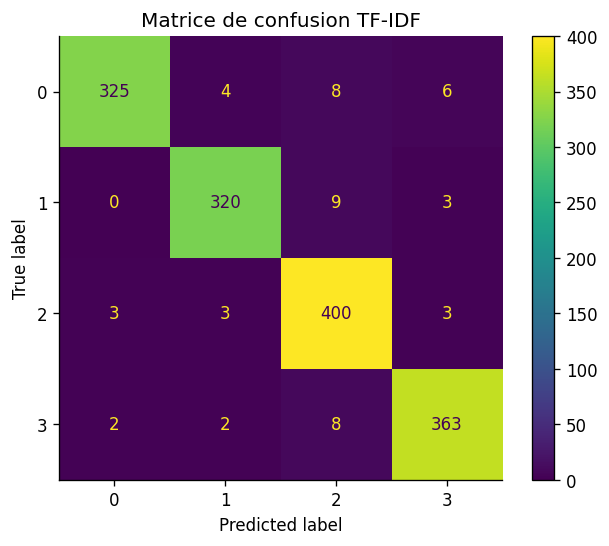


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       343
           1       0.97      0.96      0.97       332
           2       0.94      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# meilleur modèle
best_model_name = max(results_tfidf, key=lambda x: results_tfidf[x]["F1-score"])
print("\nMeilleur modèle TF-IDF :", best_model_name , f"avec F1-score={results_tfidf[best_model_name]['F1-score']:.4f}")

best_model = models_text[best_model_name]
best_model.fit(X_train_tfidf, y_train)

y_pred = best_model.predict(X_test_tfidf)

# matrice
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("Matrice de confusion TF-IDF")
plt.show()

# rapport
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

### WORD2VEC (SÉMANTIQUE)

In [12]:
# Tokenisation sur les textes prétraités
sentences = [text.split() for text in X_train_clean]

w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)


def vectorize_w2v(text: str) -> np.ndarray:
    words = text.split()
    vecs  = [w2v.wv[w] for w in words if w in w2v.wv]
    if not vecs:
        return np.zeros(100)
    return np.mean(vecs, axis=0)


X_train_w2v = np.vstack([vectorize_w2v(t) for t in X_train_clean]).astype(np.float32)
X_test_w2v  = np.vstack([vectorize_w2v(t) for t in X_test_clean]).astype(np.float32)

results_w2v = {}

for name, model in models_emb.items():
    acc, prec, rec, f1 = evaluate(model, X_train_w2v, X_test_w2v, y_train, y_test, representation="Word2Vec", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_w2v[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== Logistic Regression ===
Accuracy : 0.9623
Precision: 0.9639
Recall   : 0.9623
F1-score : 0.9626

=== Linear SVC ===
Accuracy : 0.9609
Precision: 0.9633
Recall   : 0.9609
F1-score : 0.9613

=== Random Forest ===
Accuracy : 0.9657
Precision: 0.9662
Recall   : 0.9657
F1-score : 0.9658


#### Matrice de confusion word2VEC meilleur modéle

Meilleur modèle Word2Vec : Random Forest (F1=0.9658)


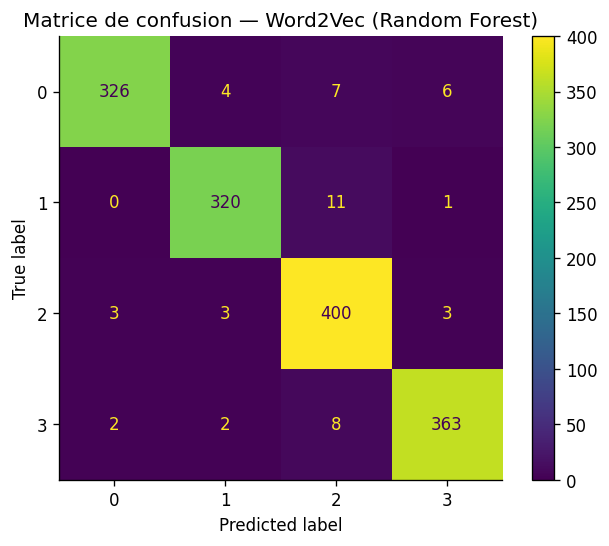


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       343
           1       0.97      0.96      0.97       332
           2       0.94      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [13]:

# MEILLEUR MODÈLE WORD2VEC
best_model_name = max(results_w2v, key=lambda x: results_w2v[x]["F1-score"])

print("Meilleur modèle Word2Vec :", best_model_name,
      f"(F1={results_w2v[best_model_name]['F1-score']:.4f})")

best_model = models_emb[best_model_name]
best_model.fit(X_train_w2v, y_train)
y_pred_best = best_model.predict(X_test_w2v)

# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Matrice de confusion — Word2Vec ({best_model_name})")
plt.show()

# CLASSIFICATION REPORT
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

### FASTTEXT

In [14]:
ft = FastText(sentences, vector_size=100, window=5, min_count=2, workers=4)


def vectorize_ft(text: str) -> np.ndarray:
    words = text.split()
    if not words:
        return np.zeros(100)
    # ft.wv[w] fonctionne même pour les mots OOV (hors vocabulaire)
    # grâce aux n-grammes de caractères — ne pas filtrer avec 'if w in ft.wv'
    vecs = [ft.wv[w] for w in words]
    return np.mean(vecs, axis=0)


X_train_ft = np.vstack([vectorize_ft(t) for t in X_train_clean]).astype(np.float32)
X_test_ft  = np.vstack([vectorize_ft(t) for t in X_test_clean]).astype(np.float32)

results_fasttext = {}

for name, model in models_emb.items():
    acc, prec, rec, f1 = evaluate(model, X_train_ft, X_test_ft, y_train, y_test, representation="FastText", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_fasttext[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


=== Logistic Regression ===
Accuracy : 0.9616
Precision: 0.9618
Recall   : 0.9616
F1-score : 0.9616

=== Linear SVC ===
Accuracy : 0.9650
Precision: 0.9667
Recall   : 0.9650
F1-score : 0.9653

=== Random Forest ===
Accuracy : 0.9650
Precision: 0.9655
Recall   : 0.9650
F1-score : 0.9651


####  Matrice de Confusion — Meilleur modèle FASTTEXT

 Meilleur modèle FastText : Linear SVC (F1=0.9653)


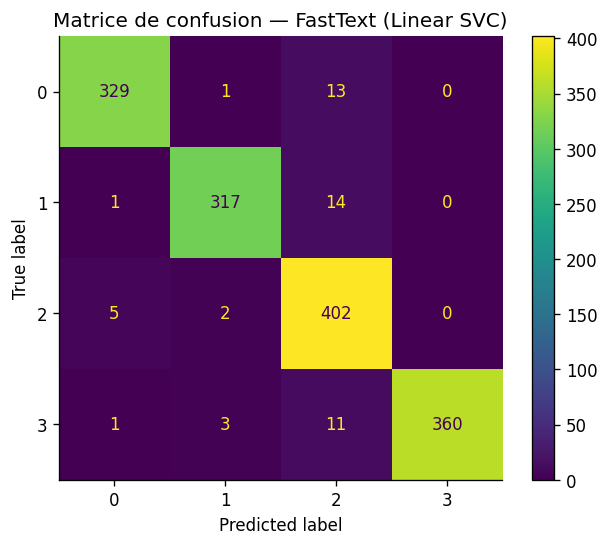


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       343
           1       0.98      0.95      0.97       332
           2       0.91      0.98      0.95       409
           3       1.00      0.96      0.98       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [15]:
# MEILLEUR MODÈLE FASTTEXT
best_model_name = max(results_fasttext, key=lambda x: results_fasttext[x]["F1-score"])

print(" Meilleur modèle FastText :", best_model_name,
      f"(F1={results_fasttext[best_model_name]['F1-score']:.4f})")

best_model = models_emb[best_model_name]
best_model.fit(X_train_ft, y_train)
y_pred_best = best_model.predict(X_test_ft)

# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"Matrice de confusion — FastText ({best_model_name})")
plt.show()

# CLASSIFICATION REPORT
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

### CAMEMBERT (BONUS — Sentence Transformers)

In [16]:

from sentence_transformers import SentenceTransformer
model_cam = SentenceTransformer("dangvantuan/sentence-camembert-base")

X_train_cam = model_cam.encode(X_train.tolist(), show_progress_bar=True)
X_test_cam  = model_cam.encode(X_test.tolist(),  show_progress_bar=True)

results_cam = {}

for name, model in models_emb.items():
    acc, prec, rec, f1 = evaluate(model, X_train_cam, X_test_cam, y_train, y_test, representation="CamemBERT", model_name=name)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results_cam[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

Batches: 100%|██████████| 46/46 [00:36<00:00,  1.27it/s]



=== Logistic Regression ===
Accuracy : 0.9815
Precision: 0.9818
Recall   : 0.9815
F1-score : 0.9815

=== Linear SVC ===
Accuracy : 0.9842
Precision: 0.9845
Recall   : 0.9842
F1-score : 0.9843

=== Random Forest ===
Accuracy : 0.9705
Precision: 0.9719
Recall   : 0.9705
F1-score : 0.9707


#### Matrice de Confusion — Meilleur modèle CAMEMBERT


 Meilleur modèle CamemBERT : Linear SVC (F1=0.9843)


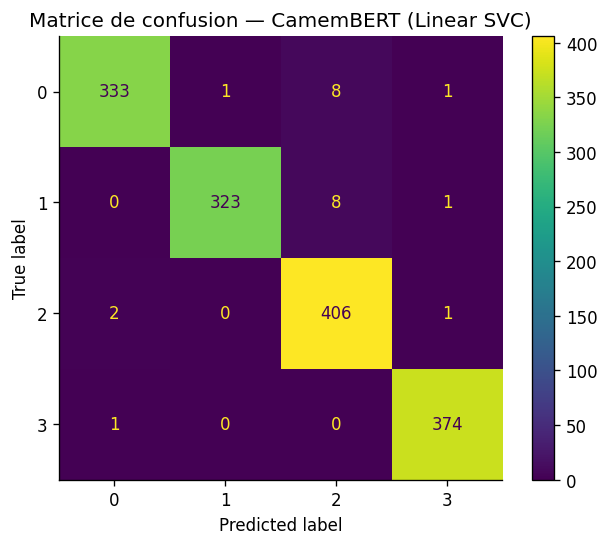


=== Classification Report (CamemBERT) ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       343
           1       1.00      0.97      0.98       332
           2       0.96      0.99      0.98       409
           3       0.99      1.00      0.99       375

    accuracy                           0.98      1459
   macro avg       0.99      0.98      0.98      1459
weighted avg       0.98      0.98      0.98      1459



In [17]:

best_model_name_cam = max(results_cam, key=lambda x: results_cam[x]["F1-score"])

print("\n Meilleur modèle CamemBERT :", best_model_name_cam,
      f"(F1={results_cam[best_model_name_cam]['F1-score']:.4f})")

best_model_cam = models_emb[best_model_name_cam]

# IMPORTANT : ré-entrainer sur tout le train
best_model_cam.fit(X_train_cam, y_train)

y_pred_best_cam = best_model_cam.predict(X_test_cam)

# MATRICE DE CONFUSION
cm_cam = confusion_matrix(y_test, y_pred_best_cam)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cam)
disp.plot()

plt.title(f"Matrice de confusion — CamemBERT ({best_model_name_cam})")
plt.show()

print("\n=== Classification Report (CamemBERT) ===")
print(classification_report(y_test, y_pred_best_cam))

### TABLEAU COMPARATIF

In [18]:
NAN = float('nan')

index_order = ['Linear SVC', 'Logistic Regression', 'Random Forest', 'Naive Bayes']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

def build_metric_df(metric):
    return pd.DataFrame(
        {
            'BoW': [
                results_bow['Linear SVC'][metric],
                results_bow['Logistic Regression'][metric],
                results_bow['Random Forest'][metric],
                results_bow['Naive Bayes'][metric],
            ],
            'TF-IDF': [
                results_tfidf['Linear SVC'][metric],
                results_tfidf['Logistic Regression'][metric],
                results_tfidf['Random Forest'][metric],
                results_tfidf['Naive Bayes'][metric],
            ],
            'Word2Vec': [
                results_w2v['Linear SVC'][metric],
                results_w2v['Logistic Regression'][metric],
                results_w2v['Random Forest'][metric],
                NAN,  # MultinomialNB incompatible avec embeddings denses
            ],
            'FastText': [
                results_fasttext['Linear SVC'][metric],
                results_fasttext['Logistic Regression'][metric],
                results_fasttext['Random Forest'][metric],
                NAN,  # MultinomialNB incompatible avec embeddings denses
            ],
            'CamemBERT': [
                results_cam['Linear SVC'][metric],
                results_cam['Logistic Regression'][metric],
                results_cam['Random Forest'][metric],
                NAN,  # MultinomialNB incompatible avec embeddings denses
            ],
        },
        index=index_order
    ).round(4)

results_all = {metric: build_metric_df(metric) for metric in metrics}

for metric, df in results_all.items():
    print(f'\n=== {metric} (test set) ===')
    print(df.to_string())


=== Accuracy (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9623  0.9637    0.9609    0.9650     0.9842
Logistic Regression  0.9623  0.9630    0.9623    0.9616     0.9815
Random Forest        0.9644  0.9650    0.9657    0.9650     0.9705
Naive Bayes          0.9650  0.9616       NaN       NaN        NaN

=== Precision (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9635  0.9644    0.9633    0.9667     0.9845
Logistic Regression  0.9635  0.9656    0.9639    0.9618     0.9818
Random Forest        0.9647  0.9655    0.9662    0.9655     0.9719
Naive Bayes          0.9666  0.9634       NaN       NaN        NaN

=== Recall (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9623  0.9637    0.9609    0.9650     0.9842
Logistic Regression  0.9623  0.9630    0.9623    0.9616     0.9815
Random Forest        0.9644  0.9650    0.96

## MODULE 5 : Pipeline Multimodal Avancé

### 5.1 Pipeline ColumnTransformer — Fusion Reproductible

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
import scipy.sparse as sp
import numpy as np
import pandas as pd
# ─── Reconstruction du DataFrame complet pour ColumnTransformer ──────────────
# On suppose que df_clean contient la colonne texte + des colonnes numériques
# Simulation des colonnes numériques si absentes (à adapter à votre dataset)

num_cols_available = [c for c in df_clean.columns
                      if c not in [text_col, target]
                      and df_clean[c].dtype in ['float64', 'int64', 'float32', 'int32']]

if len(num_cols_available) == 0:
    # Génération de features numériques synthétiques pour la démo
    print("[INFO] Aucune colonne numérique détectée — génération de features synthétiques")
    np.random.seed(42)
    df_clean["longueur_texte"]   = df_clean[text_col].str.len().astype(float)
    df_clean["nb_mots"]          = df_clean[text_col].str.split().str.len().astype(float)
    df_clean["nb_mots_uniques"]  = df_clean[text_col].apply(lambda x: len(set(str(x).split()))).astype(float)
    num_cols_available = ["longueur_texte", "nb_mots", "nb_mots_uniques"]

print(f"Colonnes numériques utilisées : {num_cols_available}")

# ─── Re-split sur le DataFrame complet ──────────────────────────────────────
from sklearn.model_selection import train_test_split

df_train_full, df_tmp = train_test_split(df_clean, test_size=0.30, random_state=42,
                                         stratify=df_clean[target])
df_val_full, df_test_full = train_test_split(df_tmp, test_size=0.50, random_state=42,
                                              stratify=df_tmp[target])

y_train_full = df_train_full[target]
y_val_full   = df_val_full[target]
y_test_full  = df_test_full[target]

print(f"Train: {len(df_train_full)} | Val: {len(df_val_full)} | Test: {len(df_test_full)}")


Colonnes numériques utilisées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Source']
Train: 6806 | Val: 1459 | Test: 1459


In [20]:
# ─── ColumnTransformer : TF-IDF (sparse) + StandardScaler (dense) ────────────

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=20_000,
                                  sublinear_tf=True), text_col),
        ("num",   StandardScaler(),                                          num_cols_available),
    ],
    remainder="drop",
    sparse_threshold=0.3   # conserve le format sparse si densité < 30 %
)

# ─── Pipelines complets ───────────────────────────────────────────────────────

pipelines_ct = {
    "LR  + CT": Pipeline([
        ("prep", preprocessor),
        ("clf",  LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    "SVC + CT": Pipeline([
        ("prep", preprocessor),
        ("clf",  LinearSVC(C=1.0, random_state=42))
    ]),
    "RF  + CT": Pipeline([
        ("prep", preprocessor),
        ("clf",  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
}

results_ct = {}

print("=== ColumnTransformer — Fusion TF-IDF + Numérique ===\n")

for name, pipe in pipelines_ct.items():
    pipe.fit(df_train_full, y_train_full)
    y_pred = pipe.predict(df_test_full)

    f1  = f1_score(y_test_full, y_pred, average="weighted", zero_division=0)
    acc = (y_pred == y_test_full.values).mean()

    results_ct[name] = {"F1-score": f1, "Accuracy": acc, "pipeline": pipe, "y_pred": y_pred}
    print(f"{name:<12} | Accuracy: {acc:.4f} | F1-score: {f1:.4f}")

best_ct_name = max(results_ct, key=lambda k: results_ct[k]["F1-score"])
print(f"\n✅ Meilleur pipeline CT : {best_ct_name}  (F1={results_ct[best_ct_name]['F1-score']:.4f})")


=== ColumnTransformer — Fusion TF-IDF + Numérique ===

LR  + CT     | Accuracy: 0.9959 | F1-score: 0.9959
SVC + CT     | Accuracy: 0.9959 | F1-score: 0.9959
RF  + CT     | Accuracy: 0.9952 | F1-score: 0.9952

✅ Meilleur pipeline CT : SVC + CT  (F1=0.9959)


Dimensions features fusionnées : TF-IDF=4263 + Num=7
Exemple features TF-IDF : ['10', '10 caractéristiques', '10 kg', '10 poids', '10 rigide', '10 rigidité', '100', '100 poids', '100 rigide', '100 rigidité']


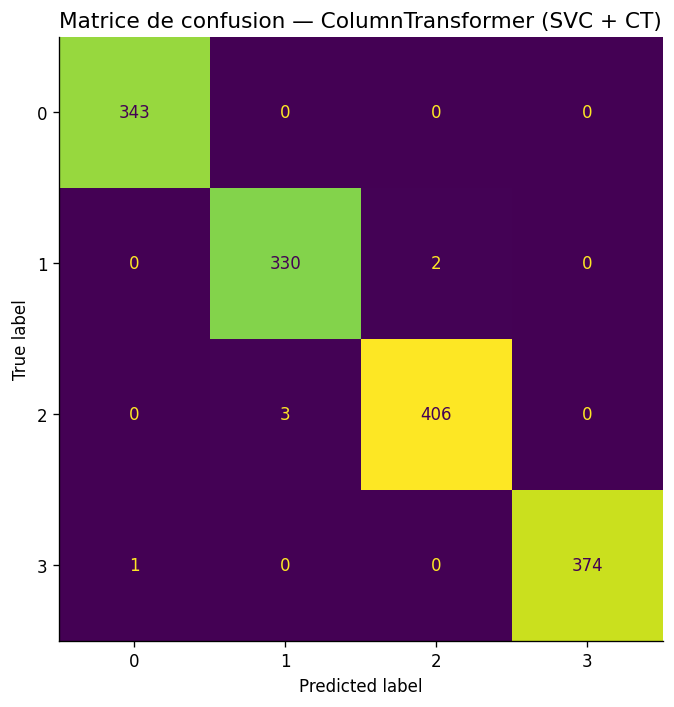


=== Classification Report (ColumnTransformer) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       0.99      0.99      0.99       332
           2       1.00      0.99      0.99       409
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1459
   macro avg       1.00      1.00      1.00      1459
weighted avg       1.00      1.00      1.00      1459



In [21]:
# ─── Visualisation des features TF-IDF après fusion ─────────────────────────
import matplotlib.pyplot as plt

best_pipe = results_ct[best_ct_name]["pipeline"]
tfidf_fitted = best_pipe.named_steps["prep"].named_transformers_["tfidf"]

feature_names = tfidf_fitted.get_feature_names_out()
print(f"Dimensions features fusionnées : TF-IDF={len(feature_names)} + Num={len(num_cols_available)}")
print(f"Exemple features TF-IDF : {feature_names[:10].tolist()}")

# ─── Matrice de confusion du meilleur pipeline CT ────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_best_ct = results_ct[best_ct_name]["y_pred"]
cm_ct = confusion_matrix(y_test_full, y_pred_best_ct)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_ct).plot(ax=ax, colorbar=False)
ax.set_title(f"Matrice de confusion — ColumnTransformer ({best_ct_name})", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Classification Report (ColumnTransformer) ===")
print(classification_report(y_test_full, y_pred_best_ct))


### 5.2 Ponderation Relative NLP / Numerique

In [ ]:
from scipy.sparse import hstack, csr_matrix

# ─── Construction manuelle des matrices sparse ────────────────────────────────

tfidf_w = TfidfVectorizer(ngram_range=(1, 2), max_features=20_000, sublinear_tf=True)
scaler_w = StandardScaler()

# Prétraitement sur train, application sur test
X_train_tfidf_w = tfidf_w.fit_transform(df_train_full[text_col].apply(preprocess))
X_test_tfidf_w  = tfidf_w.transform(df_test_full[text_col].apply(preprocess))

X_train_num_w = scaler_w.fit_transform(df_train_full[num_cols_available])
X_test_num_w  = scaler_w.transform(df_test_full[num_cols_available])


def fuse_weighted(X_tfidf, X_num, alpha=1.0):
    """Fusion sparse : TF-IDF + alpha * features numériques.
    alpha > 1 → accentue le numérique ; alpha < 1 → accentue le NLP.
    """
    X_num_sparse = csr_matrix(X_num * alpha)
    return hstack([X_tfidf, X_num_sparse])


# ─── Grid-search sur alpha ────────────────────────────────────────────────────

alphas = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
results_alpha = {}

clf_alpha = LinearSVC(C=1.0, random_state=42)

print("Alpha  | F1-score (test)")
print("-------|----------------")

for alpha in alphas:
    X_tr = fuse_weighted(X_train_tfidf_w, X_train_num_w, alpha)
    X_te = fuse_weighted(X_test_tfidf_w,  X_test_num_w,  alpha)

    clf_alpha.fit(X_tr, y_train_full)
    y_pred_a = clf_alpha.predict(X_te)
    f1_a = f1_score(y_test_full, y_pred_a, average="weighted", zero_division=0)

    results_alpha[alpha] = f1_a
    print(f"{alpha:6.2f} | {f1_a:.4f}")

best_alpha = max(results_alpha, key=results_alpha.get)
print(f"\n✅ Meilleur alpha : {best_alpha}  (F1={results_alpha[best_alpha]:.4f})")


Alpha  | F1-score (CV moyen)
-------|---------------------
  0.00 | 0.9643
  0.10 | 0.9954
  0.50 | 0.9962
  1.00 | 0.9962
  2.00 | 0.9962
  5.00 | 0.9962

✅ Meilleur alpha (CV) : 0.5 (F1=0.9962)


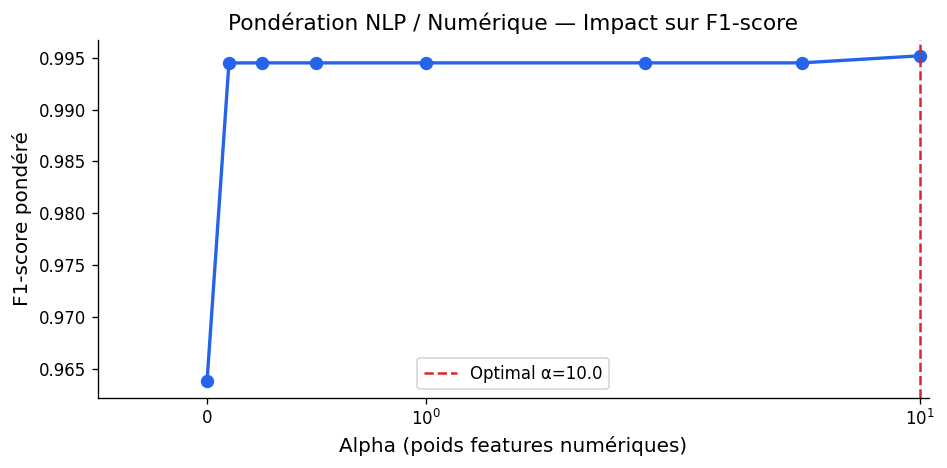


=== Classification Report (Meilleur alpha) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       0.99      0.99      0.99       332
           2       1.00      0.99      0.99       409
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1459
   macro avg       1.00      1.00      1.00      1459
weighted avg       1.00      1.00      1.00      1459



In [23]:
# ─── Courbe F1 vs Alpha ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(list(results_alpha.keys()), list(results_alpha.values()),
        marker="o", linewidth=2, color="#2563EB", markersize=7)

ax.axvline(x=best_alpha, color="#DC2626", linestyle="--", linewidth=1.5,
           label=f"Optimal α={best_alpha}")

ax.set_xlabel("Alpha (poids features numériques)", fontsize=12)
ax.set_ylabel("F1-score pondéré", fontsize=12)
ax.set_title("Pondération NLP / Numérique — Impact sur F1-score", fontsize=13)
ax.legend()
ax.set_xscale("symlog")   # échelle log symétrique pour bien voir α=0

plt.tight_layout()
plt.show()

# ─── Retrain avec le meilleur alpha ──────────────────────────────────────────

X_train_best = fuse_weighted(X_train_tfidf_w, X_train_num_w, best_alpha)
X_test_best  = fuse_weighted(X_test_tfidf_w,  X_test_num_w,  best_alpha)

clf_best_alpha = LinearSVC(C=1.0, random_state=42)
clf_best_alpha.fit(X_train_best, y_train_full)
y_pred_best_alpha = clf_best_alpha.predict(X_test_best)

print("\n=== Classification Report (Meilleur alpha) ===")
print(classification_report(y_test_full, y_pred_best_alpha))


### 5.3 Stacking de Modeles (Meta-Learning)

In [24]:
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# ─── Stacking homogène : même représentation, modèles différents ──────────────
# On utilise TF-IDF + numérique (meilleur alpha) comme représentation commune

X_train_stack = X_train_best.copy()
X_test_stack  = X_test_best.copy()

# Level-0 : estimateurs de base (LinearSVC doit être calibré pour predict_proba)
level0 = [
    ("svc_cal", CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42), cv=3)),
    ("rf",      RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)),
    ("lr",      LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
]

# Level-1 : méta-modèle logistique
stacking_clf = StackingClassifier(
    estimators=level0,
    final_estimator=LogisticRegression(max_iter=500, C=0.5, random_state=42),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False,   # True → concatène aussi les features originales
)

print("Entraînement du Stacking (cross-val interne CV=5)...")
stacking_clf.fit(X_train_stack, y_train_full)
y_pred_stack = stacking_clf.predict(X_test_stack)

f1_stack  = f1_score(y_test_full, y_pred_stack, average="weighted", zero_division=0)
acc_stack = (y_pred_stack == y_test_full.values).mean()

print(f"\nStacking — Accuracy : {acc_stack:.4f} | F1-score : {f1_stack:.4f}")
print("\n=== Classification Report (Stacking) ===")
print(classification_report(y_test_full, y_pred_stack))


Entraînement du Stacking (cross-val interne CV=5)...

Stacking — Accuracy : 0.9966 | F1-score : 0.9966

=== Classification Report (Stacking) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       1.00      0.99      0.99       332
           2       0.99      1.00      1.00       409
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1459
   macro avg       1.00      1.00      1.00      1459
weighted avg       1.00      1.00      1.00      1459



In [25]:
# ─── Stacking hétérogène : représentations différentes par modèle ─────────────
# Chaque estimateur travaille sur une représentation différente.
# Implémentation manuelle via out-of-fold predictions.

from sklearn.base import clone

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Représentations disponibles (denses + sparse converties)
X_train_bow_arr  = X_train_bow.toarray()   if sp.issparse(X_train_bow)  else X_train_bow
X_test_bow_arr   = X_test_bow.toarray()    if sp.issparse(X_test_bow)   else X_test_bow
X_train_tfidf_arr= X_train_tfidf.toarray() if sp.issparse(X_train_tfidf) else X_train_tfidf
X_test_tfidf_arr = X_test_tfidf.toarray()  if sp.issparse(X_test_tfidf) else X_test_tfidf

# Encodage des labels pour les indices OOF
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train_full)

base_configs = {
    "NB_BoW":       (MultinomialNB(),                                       X_train_bow_arr,   X_test_bow_arr),
    "SVC_TFIDF":    (CalibratedClassifierCV(LinearSVC(random_state=42)),    X_train_tfidf_arr, X_test_tfidf_arr),
    "RF_W2V":       (RandomForestClassifier(n_estimators=100, random_state=42), X_train_w2v, X_test_w2v),
}

n_classes = len(le.classes_)
oof_preds  = np.zeros((len(y_train_full), len(base_configs) * n_classes))
test_preds = np.zeros((len(y_test_full),  len(base_configs) * n_classes))

print("Construction des out-of-fold predictions...")

# Réindexation train pour aligner avec df_train_full
y_train_arr = le.transform(y_train_full.values)
y_test_arr  = le.transform(y_test_full.values)

for col_offset, (cfg_name, (clf_base, X_tr, X_te)) in enumerate(base_configs.items()):
    oof  = np.zeros((len(y_train_full), n_classes))
    test_fold = np.zeros((len(y_test_full), n_classes))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tr, y_train_arr)):
        clf_fold = clone(clf_base)
        clf_fold.fit(X_tr[tr_idx], y_train_arr[tr_idx])
        oof[val_idx] = clf_fold.predict_proba(X_tr[val_idx])
        test_fold   += clf_fold.predict_proba(X_te) / kf.n_splits

    oof_preds[:,  col_offset*n_classes:(col_offset+1)*n_classes] = oof
    test_preds[:, col_offset*n_classes:(col_offset+1)*n_classes] = test_fold
    print(f"  ✓ {cfg_name}")

# Méta-modèle
meta_clf = LogisticRegression(max_iter=500, C=0.3, random_state=42)
meta_clf.fit(oof_preds, y_train_arr)
y_pred_meta = le.inverse_transform(meta_clf.predict(test_preds))

f1_meta  = f1_score(y_test_full, y_pred_meta, average="weighted", zero_division=0)
acc_meta = (y_pred_meta == y_test_full.values).mean()

print(f"\nStacking Hétérogène — Accuracy : {acc_meta:.4f} | F1-score : {f1_meta:.4f}")
print("\n=== Classification Report (Stacking Hétérogène) ===")
print(classification_report(y_test_full, y_pred_meta))


Construction des out-of-fold predictions...
  ✓ NB_BoW
  ✓ SVC_TFIDF
  ✓ RF_W2V

Stacking Hétérogène — Accuracy : 0.9644 | F1-score : 0.9645

=== Classification Report (Stacking Hétérogène) ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       343
           1       0.98      0.96      0.97       332
           2       0.92      0.98      0.95       409
           3       0.99      0.96      0.98       375

    accuracy                           0.96      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.96      0.96      1459



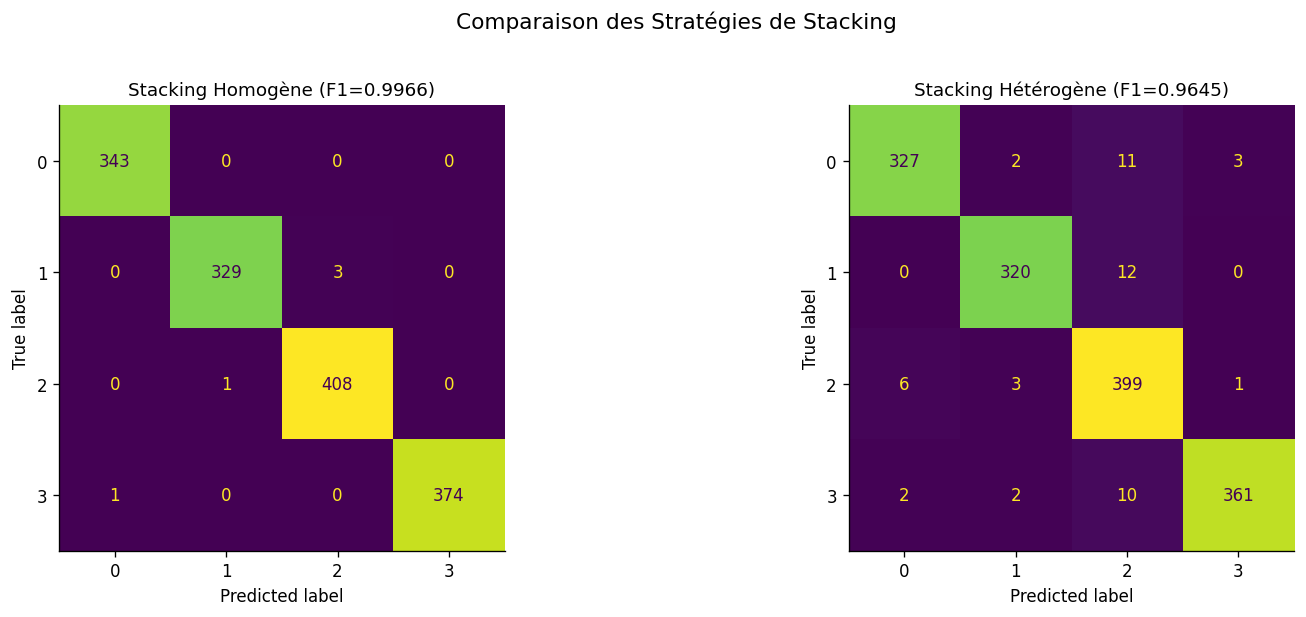

In [26]:
# ─── Matrice de confusion — Stacking ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred_plot, title_plot in [
    (axes[0], y_pred_stack, f"Stacking Homogène (F1={f1_stack:.4f})"),
    (axes[1], y_pred_meta,  f"Stacking Hétérogène (F1={f1_meta:.4f})"),
]:
    cm_plot = confusion_matrix(y_test_full, y_pred_plot)
    ConfusionMatrixDisplay(cm_plot).plot(ax=ax, colorbar=False)
    ax.set_title(title_plot, fontsize=11)

plt.suptitle("Comparaison des Stratégies de Stacking", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Synthese Comparative - Toutes Strategies de Fusion

In [27]:
# ─── Tableau comparatif final ────────────────────────────────────────────────

summary_data = {
    "Stratégie": [
        "ColumnTransformer (best)",
        f"Pondération α={best_alpha}",
        "Stacking Homogène",
        "Stacking Hétérogène",
    ],
    "Modèle": [
        best_ct_name,
        "LinearSVC",
        "LR méta + SVC/RF/LR base",
        "LR méta + NB/SVC/RF base",
    ],
    "Accuracy": [
        results_ct[best_ct_name]["Accuracy"],
        (y_pred_best_alpha == y_test_full.values).mean(),
        acc_stack,
        acc_meta,
    ],
    "F1-score": [
        results_ct[best_ct_name]["F1-score"],
        results_alpha[best_alpha],
        f1_stack,
        f1_meta,
    ],
}

df_summary = pd.DataFrame(summary_data).round(4)
df_summary["Δ vs CT"] = (df_summary["F1-score"] - df_summary["F1-score"].iloc[0]).round(4)
df_summary = df_summary.sort_values("F1-score", ascending=False).reset_index(drop=True)

print("=== Synthèse Module 5 — Pipeline Multimodal ===\n")
print(df_summary.to_string(index=False))

best_strategy = df_summary.iloc[0]["Stratégie"]
best_f1       = df_summary.iloc[0]["F1-score"]
print(f"\n✅ Meilleure stratégie de fusion : {best_strategy}  (F1={best_f1:.4f})")


=== Synthèse Module 5 — Pipeline Multimodal ===

               Stratégie                   Modèle  Accuracy  F1-score  Δ vs CT
       Stacking Homogène LR méta + SVC/RF/LR base    0.9966    0.9966   0.0007
ColumnTransformer (best)                 SVC + CT    0.9959    0.9959   0.0000
      Pondération α=10.0                LinearSVC    0.9952    0.9952  -0.0007
     Stacking Hétérogène LR méta + NB/SVC/RF base    0.9644    0.9645  -0.0314

✅ Meilleure stratégie de fusion : Stacking Homogène  (F1=0.9966)


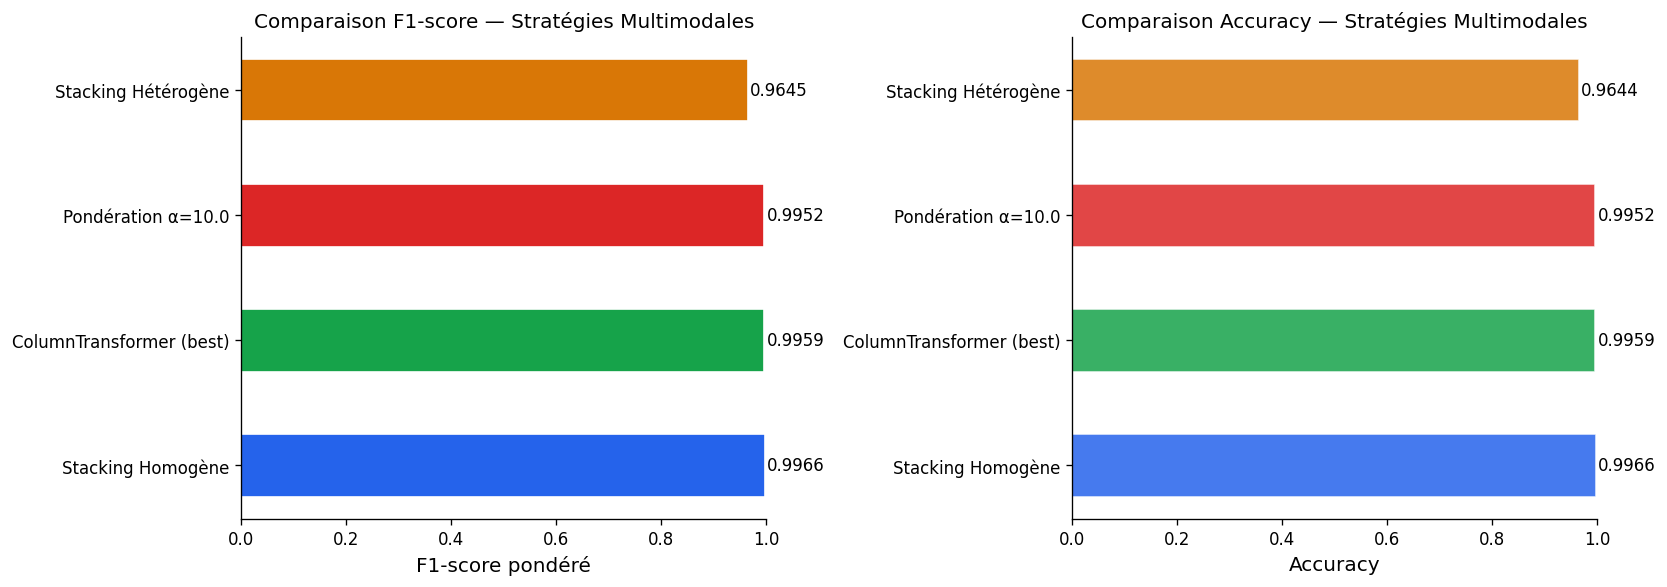

In [28]:
# ─── Visualisation comparative radar + barplot ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot F1-score
colors = ["#2563EB", "#16A34A", "#DC2626", "#D97706"]
bars = axes[0].barh(df_summary["Stratégie"], df_summary["F1-score"],
                    color=colors[:len(df_summary)], edgecolor="white", height=0.5)
axes[0].set_xlabel("F1-score pondéré", fontsize=12)
axes[0].set_title("Comparaison F1-score — Stratégies Multimodales", fontsize=12)
axes[0].set_xlim(0, 1.0)
for bar, val in zip(bars, df_summary["F1-score"]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=10)

# ── Barplot Accuracy
axes[1].barh(df_summary["Stratégie"], df_summary["Accuracy"],
             color=colors[:len(df_summary)], edgecolor="white", height=0.5, alpha=0.85)
axes[1].set_xlabel("Accuracy", fontsize=12)
axes[1].set_title("Comparaison Accuracy — Stratégies Multimodales", fontsize=12)
axes[1].set_xlim(0, 1.0)
for i, (_, row) in enumerate(df_summary.iterrows()):
    axes[1].text(row["Accuracy"] + 0.005, i, f"{row['Accuracy']:.4f}",
                 va="center", fontsize=10)

plt.tight_layout()
plt.show()


In [29]:
# ─── Récapitulatif MLflow — Module 5 ─────────────────────────────────────────

import mlflow

exp5 = mlflow.set_experiment("EcoSmart_Module5_Multimodal")

strategies_to_log = [
    ("ColumnTransformer",  results_ct[best_ct_name]["Accuracy"],     results_ct[best_ct_name]["F1-score"]),
    ("Ponderation_alpha",  (y_pred_best_alpha == y_test_full.values).mean(), results_alpha[best_alpha]),
    ("Stacking_Homogene",  acc_stack,  f1_stack),
    ("Stacking_Heterogene",acc_meta,   f1_meta),
]

for strat_name, acc_log, f1_log in strategies_to_log:
    with mlflow.start_run(experiment_id=exp5.experiment_id, run_name=strat_name):
        mlflow.set_tag("module", "5_multimodal")
        mlflow.set_tag("strategy", strat_name)
        mlflow.log_metric("accuracy", acc_log)
        mlflow.log_metric("f1_weighted", f1_log)

print("✅ Runs MLflow enregistrés pour le Module 5")
print("\n=== MODULE 5 TERMINÉ ===")
print(f"Meilleure stratégie : {best_strategy}  |  F1-score : {best_f1:.4f}")


2026/05/04 16:10:17 INFO mlflow.tracking.fluent: Experiment with name 'EcoSmart_Module5_Multimodal' does not exist. Creating a new experiment.


✅ Runs MLflow enregistrés pour le Module 5

=== MODULE 5 TERMINÉ ===
Meilleure stratégie : Stacking Homogène  |  F1-score : 0.9966


### Analyse de Performance — Modèle Multimodal vs Numérique seul